# Teste de treinamento de modelo para predição de Slump utilizando HGBR

In [9]:
%%capture
!pip install lightgbm optuna

In [10]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.inspection import permutation_importance
from lightgbm import early_stopping
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns
import pandas as pd
import numpy as np
import os

### Montagem do drive

In [11]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/slump'
filename = 'df_slump_HGBR.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Slump_mm'].copy()
df.drop(inplace=True, columns=['Slump_mm'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   Finura_Cimento_Blaine_m2_kg      126 non-null    float64 
 1   Finura_Filer_Blaine_m2_kg        126 non-null    float64 
 2   D_Max                            126 non-null    float64 
 3   Filer_Calcario_kg_m3             126 non-null    float64 
 4   Relacao_Agua_Cimento             126 non-null    float64 
 5   Idade_Dias                       126 non-null    int64   
 6   Densidade_Concreto_Fresco_kg_m3  126 non-null    float64 
 7   Resistencia_Compressao_MPa       126 non-null    float64 
 8   Tipo_Molde_Cod                   126 non-null    int64   
 9   Classe_Cim_OpA                   126 non-null    int64   
 10  Metodo_Sub_Cod                   126 non-null    int64   
 11  Usa_SP                           126 non-null    int8    
 12  cod_clas

In [13]:
n_groups = df['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 13


In [30]:
# O Dicionário de Restrições Físicas para a Reologia (Slump)
# 1 = Positiva (Aumenta o Slump)
# -1 = Negativa (Diminui o Slump)
# 0 = Livre (Ponto ótimo ou Categórica)
regras_reologia = {
    'Agregado_Graudo_Total_kg_m3': -1,      # Mais brita = Menos slump
    'Metodo_Emp_Cod': 0,                    # Categórica = Livre
    'vol_ar_aprisionado': 1,                # Mais ar (rolamento) = Mais slump
    'vol_agregados': -1,                    # Mais esqueleto total = Menos slump
    'packing_density_proxy': 0,             # Efeito parábola (ponto ótimo de finos) = Livre
    'indice_lubrificacao_global_vol': 1,    # Mais química/água = Mais slump
    'fluido_lubrificante_total': 1,         # Mais fluido base = Mais slump
    'fator_agua_finos_reverso': 1,          # Pasta mais molhada = Mais slump
    'lubrificacao_efetiva': 1               # Lubrificação sem segregação = Mais slump
}

restricoes_completas = []

for coluna in df.columns:

    restricao = regras_reologia.get(coluna, 0)

    restricoes_completas.append(restricao)

    print(f"{coluna}: {restricao}")

hyper_params = {

    # boosting
    "n_estimators": 250,
    "learning_rate": 0.05,

    # árvore
    "max_depth": 3,
    "max_bin": 64,

    # regularização
    "min_child_samples": 12,
    "reg_lambda": 10.0,

    # monotonicidade
    #"monotone_constraints": restricoes_completas,

    # reprodutibilidade
    "random_state": 42,

    # performance
    "verbosity": -1,

    # opcional
    "objective": "regression",
    "metric": "rmse",

    "device": "gpu"  # Use GPU if available
}

Finura_Cimento_Blaine_m2_kg: 0
Finura_Filer_Blaine_m2_kg: 0
D_Max: 0
Filer_Calcario_kg_m3: 0
Relacao_Agua_Cimento: 0
Idade_Dias: 0
Densidade_Concreto_Fresco_kg_m3: 0
Resistencia_Compressao_MPa: 0
Tipo_Molde_Cod: 0
Classe_Cim_OpA: 0
Metodo_Sub_Cod: 0
Usa_SP: 0
cod_classe: 0
Cluster_ID: 0
Massa_Esp_Cimento_kg_m3: 0
Massa_Esp_Areia_kg_m3: 0
Massa_Esp_Brita_kg_m3: 0
Massa_Esp_Filer_kg_m3: 0
vol_cimento: 0
vol_brita: 0
vol_ar_aprisionado: 1
vol_aglomerante: 0
vol_agregados: -1
vol_argamassa: 0
vol_total: 0
massa_aglomerante_total: 0
vol_agua_livre: 0
fracao_vol_pasta: 0
agua_aglomerante_vol: 0
relacao_areia_brita_vol: 0
agua_equivalente_vol: 0
indice_lubrificacao_global: 0
rigidez_pasta: 0
yield_stress_proxy: 0
agua_sobre_areia: 0
potencial_segregacao: 0
fluido_lubrificante_total: 1
fator_agua_finos: 0
lubrificacao_efetiva: 1
lyse_water_demand: 0
reologia_global_proxy: 0
Autores/ano: 0
bins: 0
target: 0


In [31]:
df.columns

Index(['Finura_Cimento_Blaine_m2_kg', 'Finura_Filer_Blaine_m2_kg', 'D_Max',
       'Filer_Calcario_kg_m3', 'Relacao_Agua_Cimento', 'Idade_Dias',
       'Densidade_Concreto_Fresco_kg_m3', 'Resistencia_Compressao_MPa',
       'Tipo_Molde_Cod', 'Classe_Cim_OpA', 'Metodo_Sub_Cod', 'Usa_SP',
       'cod_classe', 'Cluster_ID', 'Massa_Esp_Cimento_kg_m3',
       'Massa_Esp_Areia_kg_m3', 'Massa_Esp_Brita_kg_m3',
       'Massa_Esp_Filer_kg_m3', 'vol_cimento', 'vol_brita',
       'vol_ar_aprisionado', 'vol_aglomerante', 'vol_agregados',
       'vol_argamassa', 'vol_total', 'massa_aglomerante_total',
       'vol_agua_livre', 'fracao_vol_pasta', 'agua_aglomerante_vol',
       'relacao_areia_brita_vol', 'agua_equivalente_vol',
       'indice_lubrificacao_global', 'rigidez_pasta', 'yield_stress_proxy',
       'agua_sobre_areia', 'potencial_segregacao', 'fluido_lubrificante_total',
       'fator_agua_finos', 'lubrificacao_efetiva', 'lyse_water_demand',
       'reologia_global_proxy', 'Autores/ano', 'b

In [32]:
%%time
X = df.drop(columns=['target', 'Autores/ano'])
y = df['target']
groups = df['Autores/ano']

all_preds = []
all_true = []
all_groups = []

results = []
importancias = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model = LGBMRegressor(**hyper_params)

    model.fit(
        X_train,
        y_train,

        eval_set=[
            (X_train, y_train),
            (X_val, y_val)
        ],

        eval_metric='rmse',

        callbacks=[
            early_stopping(50)
        ]
    )

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

    results.append(model.evals_result_)

    importancias.append(model.feature_importances_)

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[79]	training's rmse: 9.5431	valid_1's rmse: 4.55342


ValueError: Circular reference detected

In [34]:
train_curves = []
val_curves = []

for r in results:

    train_curves.append(
        r['training']['rmse']
    )

    val_curves.append(
        r['valid_1']['rmse']
    )

max_len = max(len(c) for c in train_curves)

train_matrix = np.full(
    (len(train_curves), max_len),
    np.nan
)

val_matrix = np.full(
    (len(val_curves), max_len),
    np.nan
)

for i, curve in enumerate(train_curves):
    train_matrix[i, :len(curve)] = curve

for i, curve in enumerate(val_curves):
    val_matrix[i, :len(curve)] = curve

train_mean = np.nanmean(train_matrix, axis=0)
train_std = np.nanstd(train_matrix, axis=0)

val_mean = np.nanmean(val_matrix, axis=0)
val_std = np.nanstd(val_matrix, axis=0)

iterations = np.arange(max_len)

plt.figure(figsize=(10, 6))

# treino
plt.plot(
    iterations,
    train_mean,
    label='Treino'
)

# validação
plt.plot(
    iterations,
    val_mean,
    label='Validação'
)

# faixa treino
plt.fill_between(
    iterations,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)

# faixa validação
plt.fill_between(
    iterations,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)

plt.xlabel('Iterações')
plt.ylabel('RMSE')

plt.title('Curva Média de Aprendizado - LightGBM')

plt.legend()

plt.grid(alpha=0.3)

plt.show()

ValueError: max() iterable argument is empty

In [ ]:
# Estatísticas finais
train_final = train_rmse[-1]
val_final = val_rmse[-1]
overfitting_gap = val_final - train_final

print("\n" + "="*60)
print("📊 ANÁLISE DE OVERFITTING E PERFORMANCE")
print("="*60)
print(f"✅ RMSE Treino (final):      {train_final:.6f}")
print(f"⚠️  RMSE Validação (final):   {val_final:.6f}")
print(f"📈 Gap (Val - Train):        {overfitting_gap:.6f}")
print("="*60)


📊 ANÁLISE DE OVERFITTING E PERFORMANCE
✅ RMSE Treino (final):      -242.894761
⚠️  RMSE Validação (final):   -327.302245
📈 Gap (Val - Train):        -84.407484


In [ ]:
# Fazer predições no conjunto de teste
y_pred = model.predict(X_test)
debug_df = X_test.copy()

debug_df["pred"] = y_pred
debug_df["ground_truth"] = y_test
debug_df["residual"] = debug_df["ground_truth"] - debug_df["pred"]

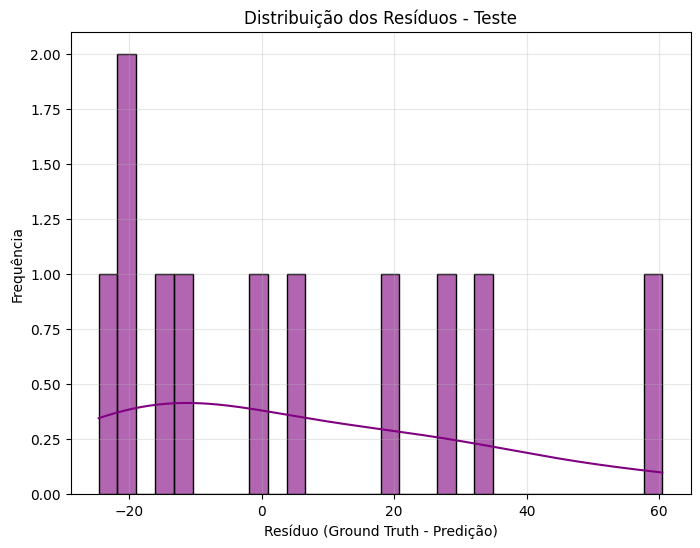

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(debug_df["residual"], bins=30, kde=True, color='purple', alpha=0.6)
plt.title("Distribuição dos Resíduos - Teste")
plt.xlabel("Resíduo (Ground Truth - Predição)")
plt.ylabel("Frequência")
plt.grid(True, alpha=0.3)
plt.show()

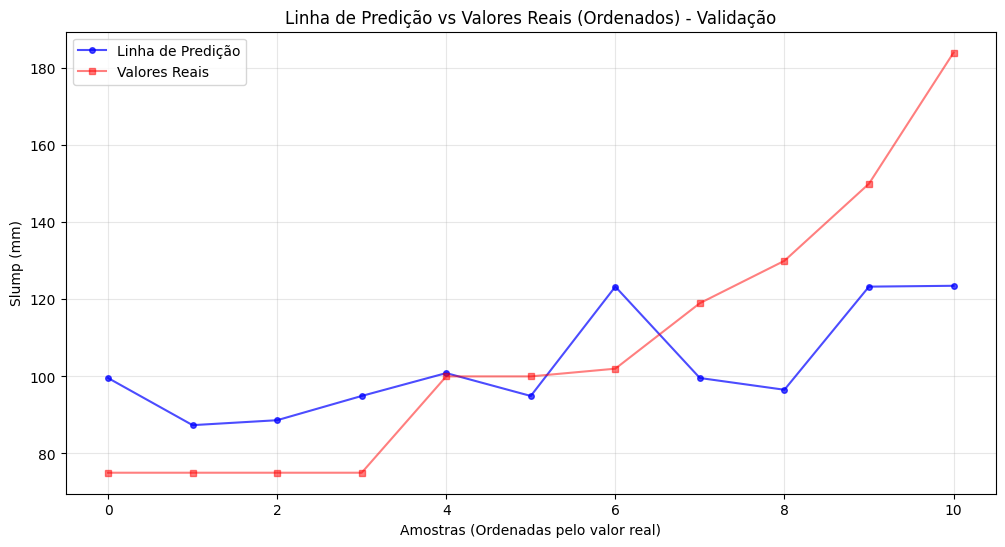

In [ ]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = debug_df.sort_values(by="ground_truth").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["ground_truth"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados) - Validação")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Slump (mm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
r2 = r2_score(debug_df["ground_truth"], debug_df["pred"])
rmse = root_mean_squared_error(debug_df["ground_truth"], debug_df["pred"])
mae = mean_absolute_error(debug_df["ground_truth"], debug_df["pred"])
mape = mean_absolute_percentage_error(debug_df["ground_truth"], debug_df["pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 26.4371
mean_absolute_error: 21.6175
mean_absolute_percentage_error: 0.1941
R² Score: 39.2923


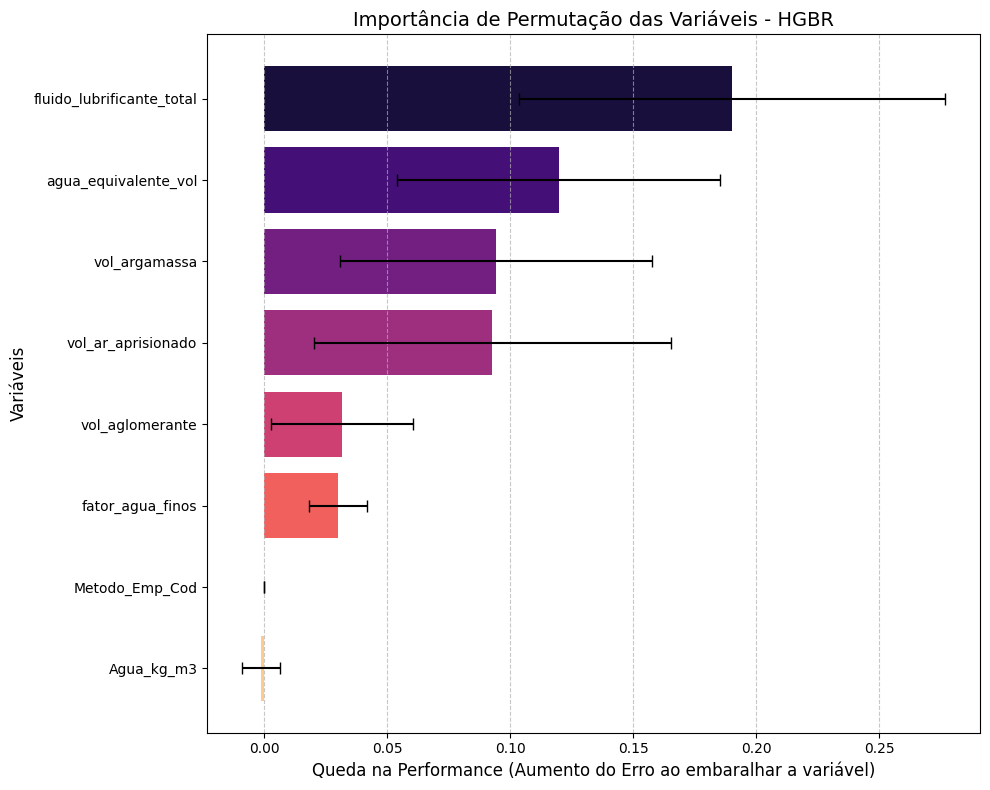

In [ ]:
# Isso mostra quais features realmente importam para prever dados NOVOS, e não apenas o que ele decorou.
resultado_permutacao = permutation_importance(
    model, X_test, y_test, 
    n_repeats=10,        # Ele vai embaralhar cada coluna 10 vezes para tirar uma média segura
    random_state=42, 
    n_jobs=-1            # Usa todos os núcleos do seu processador
)

# 2. Criando um DataFrame com os resultados
df_importancia_hgbr = pd.DataFrame({
    'Feature': X_train.columns,
    'Importancia_Media': resultado_permutacao.importances_mean,
    'Desvio_Padrao': resultado_permutacao.importances_std
})

# Ordenando da mais importante para a menos importante
df_importancia_hgbr = df_importancia_hgbr.sort_values(by='Importancia_Media', ascending=False)

# 3. Plotando o Gráfico (Solução sem o bug do Seaborn)
plt.figure(figsize=(10, 8))

# Extraindo a paleta de cores do Seaborn para manter o estilo
cores = sns.color_palette('magma', n_colors=len(df_importancia_hgbr))

# Usando o barh (Bar Horizontal) nativo do Matplotlib, que aceita o xerr perfeitamente
plt.barh(
    y=df_importancia_hgbr['Feature'], 
    width=df_importancia_hgbr['Importancia_Media'],
    xerr=df_importancia_hgbr['Desvio_Padrao'], 
    color=cores,
    capsize=4,        # Coloca aqueles "tracinhos" verticais na ponta da barra de erro
    edgecolor='none'
)

# Invertemos o eixo Y para a feature mais importante ficar no topo
plt.gca().invert_yaxis()

plt.title('Importância de Permutação das Variáveis - HGBR', fontsize=14)
plt.xlabel('Queda na Performance (Aumento do Erro ao embaralhar a variável)', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()